This notebook plots Fig. 2B, 2D-H, S1B-C, and S2A-D and uses input from "1. snRNA-seq 1 - initial processing and input preparation".

## Setup


In [1]:
# Set paths
SOD1_RENV_RNA="/oak/stanford/groups/agitler/Shared/Shared_Jupyter_Notebook_Analysis/4.1.1-OG-RNA/"
SOD1_RNA_DIR="/oak/stanford/groups/agitler/Shared/SOD1_Paper/RNA"

renv::load(SOD1_RENV_RNA)

# Load packages
suppressPackageStartupMessages({
  library(Seurat)
  library(SoupX)
  library(ggplot2)
  library(dplyr)
  library(BiocParallel)
  library(scDblFinder)
  library(svglite)
  library(pheatmap)
  library(matrixStats)
  library(tibble)
  library(DESeq2)
  library(VennDiagram)
  library(grid)
  library(stringr)
  library(ggrepel)
  library(ggrastr)
  library(ggpubr)
  library(forcats)
  library(ggbreak)
  library(cowplot)
})

## Input Paths


In [2]:
# Checkpoint and result-table inputs
all_integrated_nodub_file <- file.path(SOD1_RNA_DIR, "rds_files", "all_integrated_nodub_final.rds")
all_integrated_annotated_file <- file.path(SOD1_RNA_DIR, "rds_files", "all_integrated_annotated_final.rds")
cholinergic_subset_file <- file.path(SOD1_RNA_DIR, "rds_files", "cholinergic_subset.rds")
cholinergic_annotated_file <- file.path(SOD1_RNA_DIR, "rds_files", "cholinergic_annotated.rds")

downsampled_cholinergic_end_dir <- file.path(SOD1_RNA_DIR, "DESeq2", "Downsampled_Cholinergic_Type")
downsampled_cholinergic_mid_dir <- file.path(SOD1_RNA_DIR, "DESeq2", "Downsampled_Cholinergic_Type_Mid")
downsampled_cholinergic_early_dir <- file.path(SOD1_RNA_DIR, "DESeq2", "Downsampled_Cholinergic_Type_early")
cholinergic_type_dir <- file.path(SOD1_RNA_DIR, "DESeq2", "Cholinergic_Type")
nerve_injury_file <- file.path(SOD1_RNA_DIR, "shadrach_2021_nerve_injury.csv")

## All-Cell UMAP and Annotation-Support Marker Heatmap


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



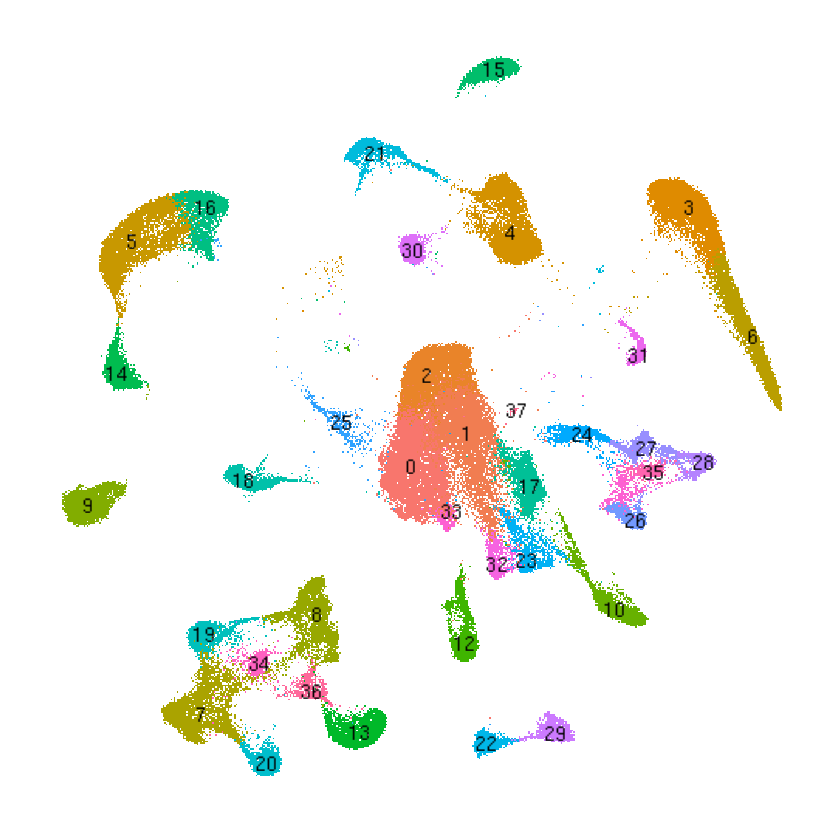

In [3]:
# All-cell UMAP by cluster
all_integrated_nodub <- readRDS(file = all_integrated_nodub_file)

all_integrated_nodub_dimplot <- DimPlot(all_integrated_nodub, reduction = "umap", label = TRUE) + NoAxes() + NoLegend() + theme(plot.title = element_blank())
all_integrated_nodub_dimplot

Warning message:
“The following 1 features were not found in the integrated assay: Slc32a1”


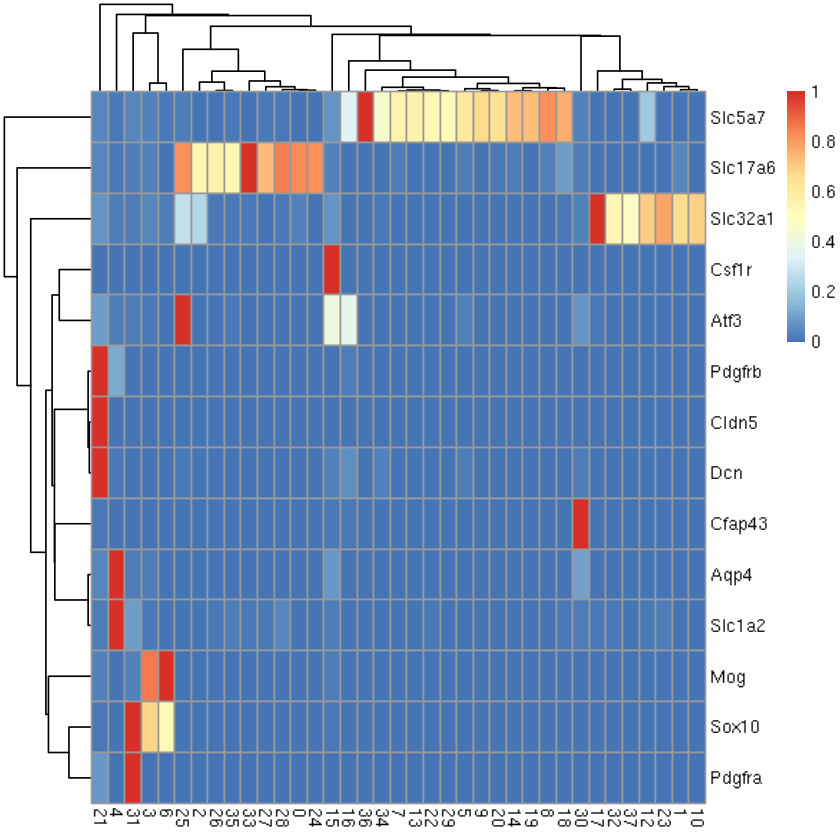

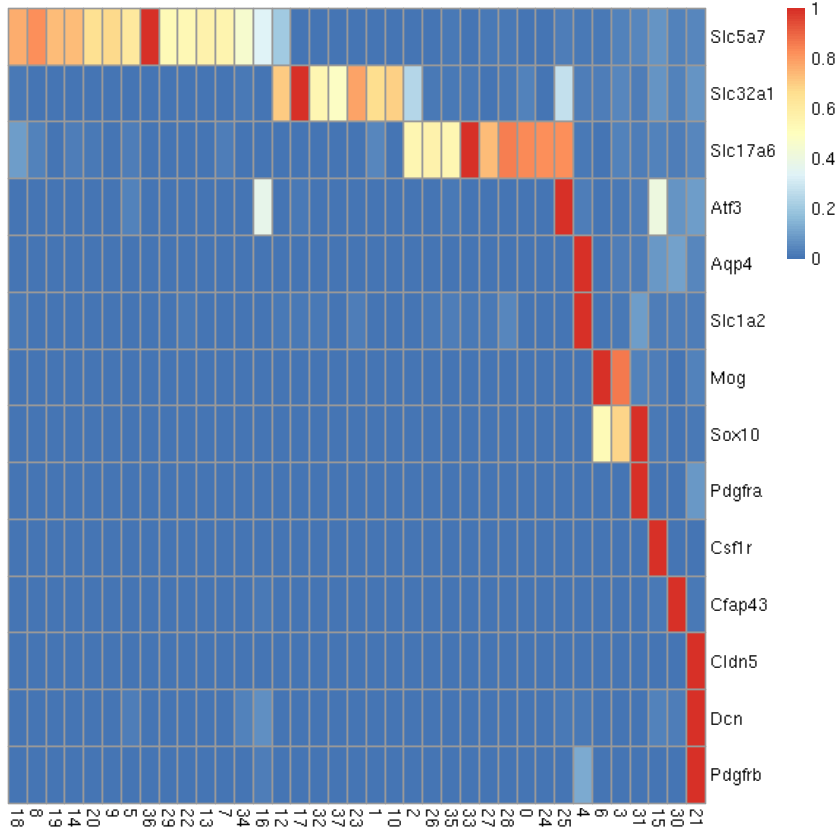

In [4]:
# Annotation-support marker heatmap
excitatory_markers <- c('Slc17a6')
inhibitory_markers <- c('Slc32a1')
astro_markers <- c('Aqp4', 'Slc1a2')
microglia_markers <- c('Csf1r')
endo_fibro_markers <- c('Cldn5', 'Dcn', 'Pdgfrb')
oligo_markers <- c('Mog', 'Sox10')
cholin_markers <- c('Slc5a7')
ependymal_markers <- c('Cfap43')
opc_markers <- c('Pdgfra')
disease_markers <- c('Atf3')

all.markers <- c(excitatory_markers, inhibitory_markers, cholin_markers, oligo_markers,
                 astro_markers, microglia_markers, endo_fibro_markers, ependymal_markers, opc_markers,
                 disease_markers)

DefaultAssay(all_integrated_nodub) <- "RNA"

Idents(all_integrated_nodub) <- all_integrated_nodub$seurat_clusters
heatmap.avgexp <- AverageExpression(all_integrated_nodub, features=all.markers)$RNA
heatmap.avgexp <- (heatmap.avgexp - rowMins(heatmap.avgexp))/(rowMaxs(heatmap.avgexp) - rowMins(heatmap.avgexp))

pheatmap(heatmap.avgexp)

row_order <- c('18','8','19','14','20','9','5','36','29','22','13','7','34','16','12','17','32','37','23','1','10','2','26','35','33','27','28','0','24','25','4','6','3','31','15','30','21')
heatmap.avgexp <- heatmap.avgexp[,row_order]

col_order <- c('Slc5a7','Slc32a1','Slc17a6','Atf3','Aqp4','Slc1a2','Mog','Sox10','Pdgfra','Csf1r','Cfap43','Cldn5','Dcn','Pdgfrb')
heatmap.avgexp <- heatmap.avgexp[col_order,]

pheatmap(heatmap.avgexp, cluster_rows = FALSE, cluster_cols = FALSE)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



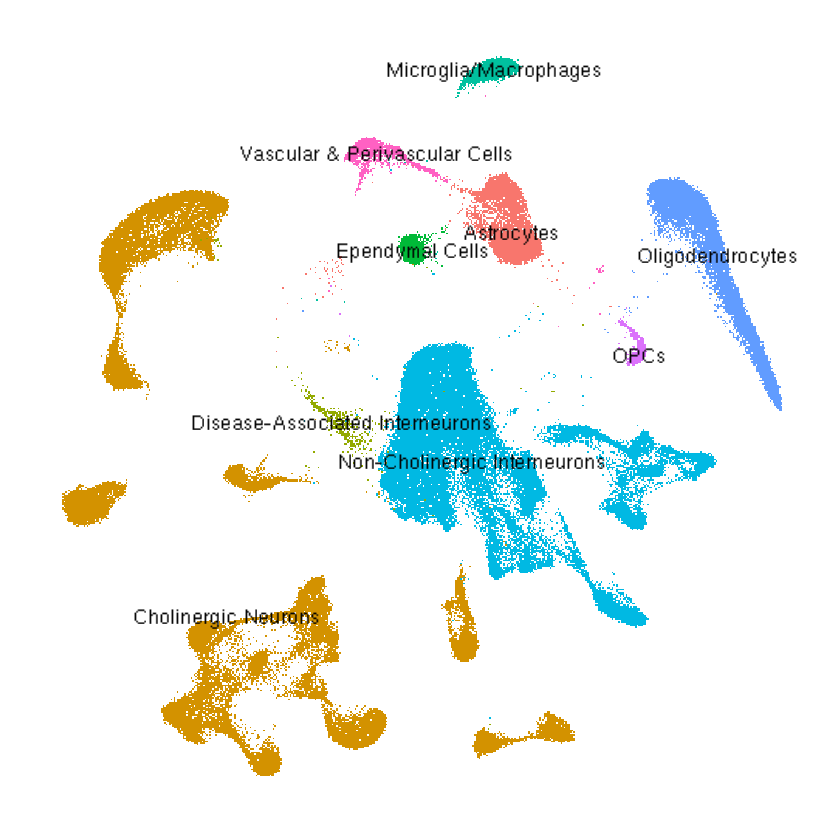

In [5]:
# All-cell UMAP by annotation
all_integrated_annotated <- readRDS(file = all_integrated_annotated_file)

all_integrated_annotated_dimplot <- DimPlot(all_integrated_annotated, reduction = "umap", group.by = "cell_class", label = TRUE) + NoAxes() + NoLegend() + theme(plot.title = element_blank())
all_integrated_annotated_dimplot

## Cholinergic UMAP/Subtype Annotation and Marker Heatmaps


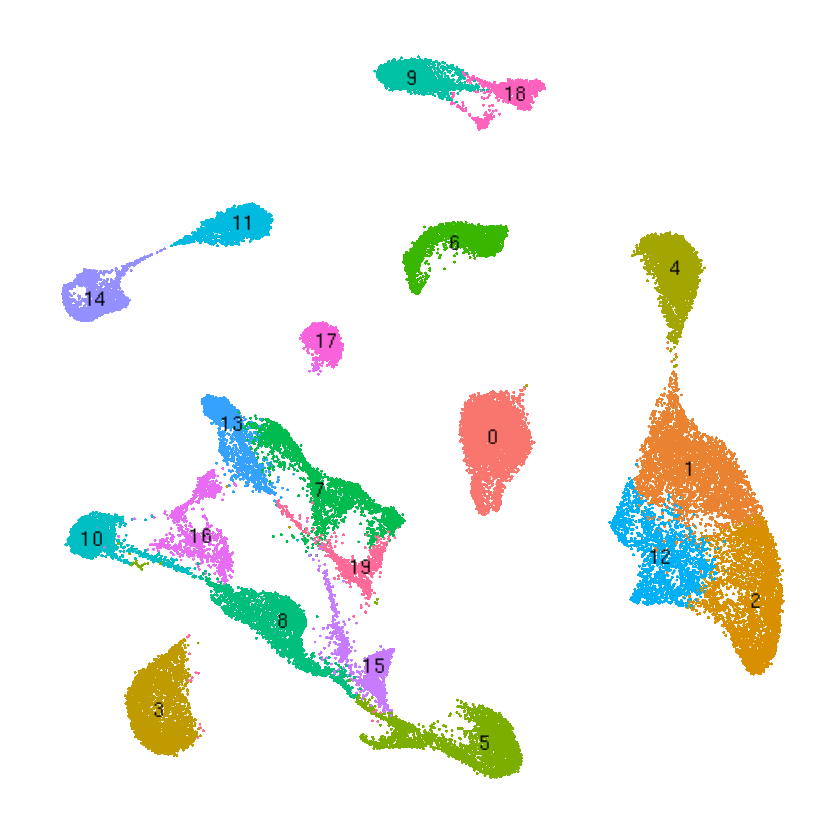

In [6]:
# Cholinergic neuron UMAP by cluster
cholinergic_subset <- readRDS(file = cholinergic_subset_file)

cholinergic_dimplot <- DimPlot(cholinergic_subset, reduction = "umap", label = TRUE) + NoLegend() + NoAxes() + NoLegend() + theme(plot.title = element_blank())
cholinergic_dimplot <- rasterize(cholinergic_dimplot, layers='Point', dpi=1000)
cholinergic_dimplot

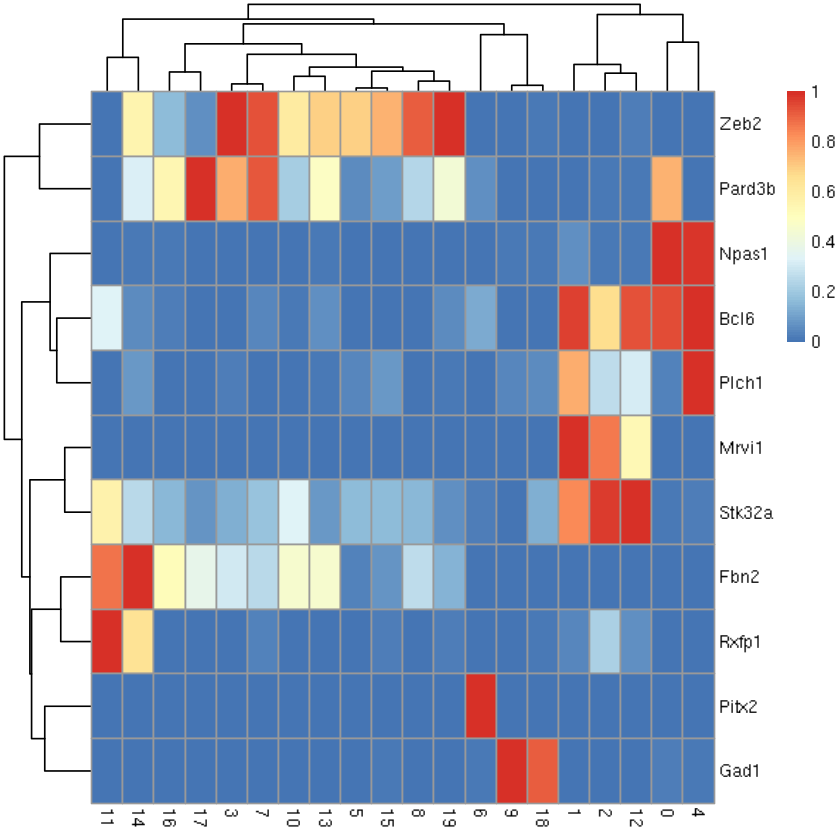

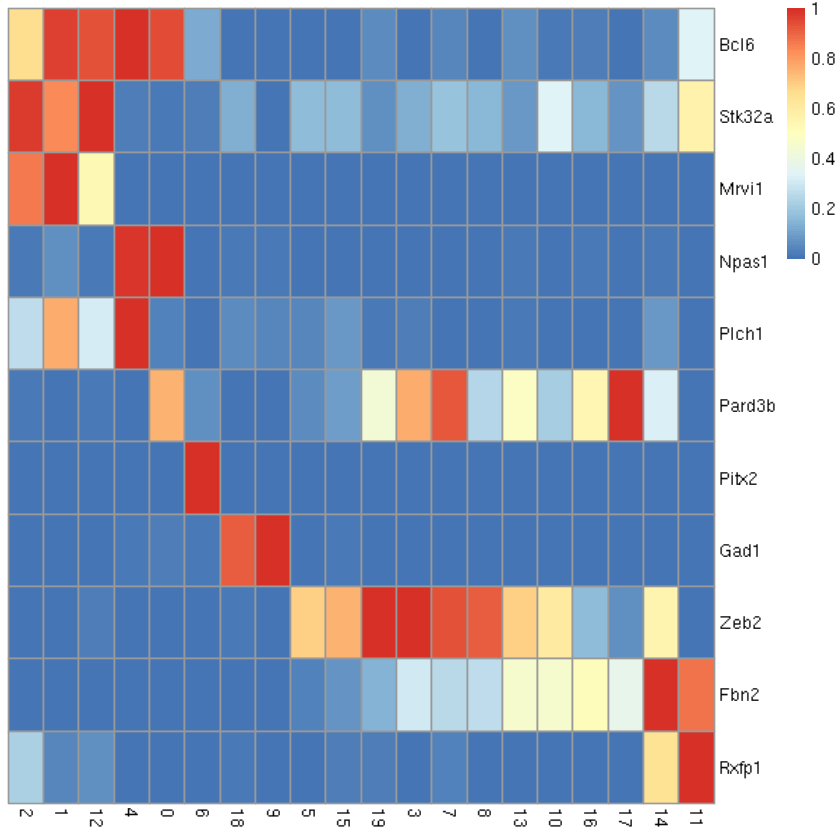

In [7]:
# Annotation-support marker heatmap
all.markers <- c(
    "Bcl6", #Skeletal
    "Fbn2", "Zeb2", #Visceral
    "Rxfp1", #Sacral visceral
    "Pitx2", #Pitx2+
    "Gad1", #Inhibitory
    "Mrvi1", "Stk32a", #Alpha
    "Npas1", #Pan-gamma
    "Plch1", #Gamma*
    "Pard3b" #Gamma
  )

DefaultAssay(cholinergic_subset) <- "RNA"

Idents(cholinergic_subset) <- cholinergic_subset$seurat_clusters
heatmap.avgexp <- AverageExpression(cholinergic_subset, features=all.markers)$RNA
heatmap.avgexp <- (heatmap.avgexp - rowMins(heatmap.avgexp))/(rowMaxs(heatmap.avgexp) - rowMins(heatmap.avgexp))
pheatmap(heatmap.avgexp)

col_order <- c('2','1','12','4','0','6','18','9','5','15','19','3','7','8','13','10','16','17','14','11')
heatmap.avgexp <- heatmap.avgexp[,col_order]

row_order <- c('Bcl6','Stk32a','Mrvi1','Npas1','Plch1','Pard3b','Pitx2','Gad1','Zeb2','Fbn2','Rxfp1')
heatmap.avgexp <- heatmap.avgexp[row_order,]

pheatmap(heatmap.avgexp, cluster_rows = FALSE, cluster_cols = FALSE)

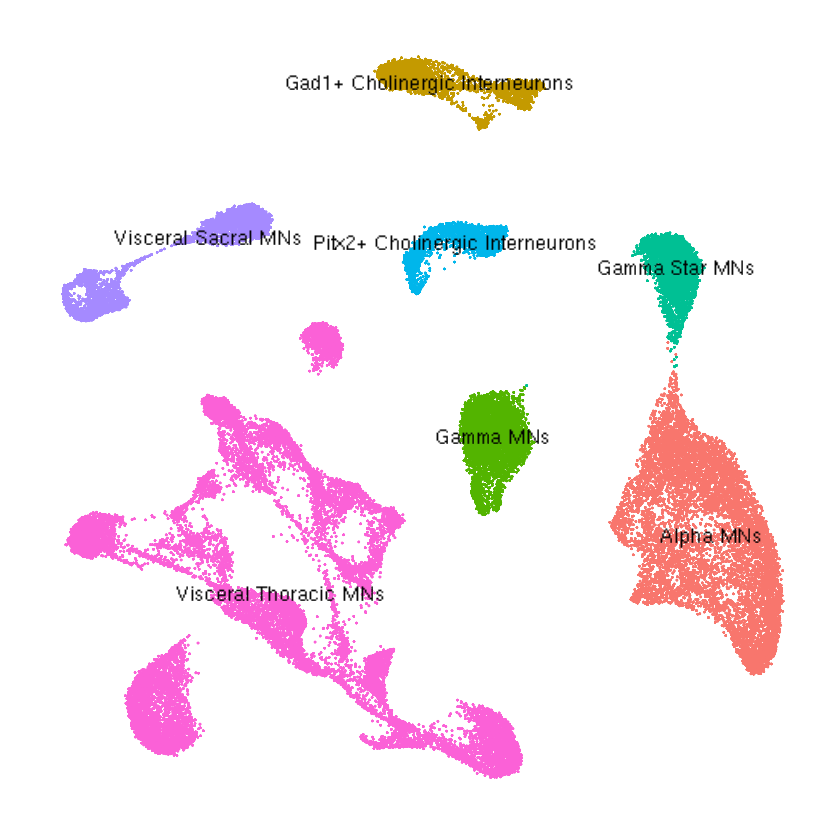

In [8]:
# Cholinergic neuron UMAP by annotation
cholinergic_annotated <- readRDS(file = cholinergic_annotated_file)

cholinergic_annotated_dimplot <- DimPlot(cholinergic_annotated, reduction = "umap", group.by = "cholinergic_type", label = TRUE) + NoAxes() + NoLegend() + theme(plot.title = element_blank())
cholinergic_annotated_dimplot <- rasterize(cholinergic_annotated_dimplot, layers='Point', dpi=500)
cholinergic_annotated_dimplot

## Cholinergic DEG Count Plots


Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.



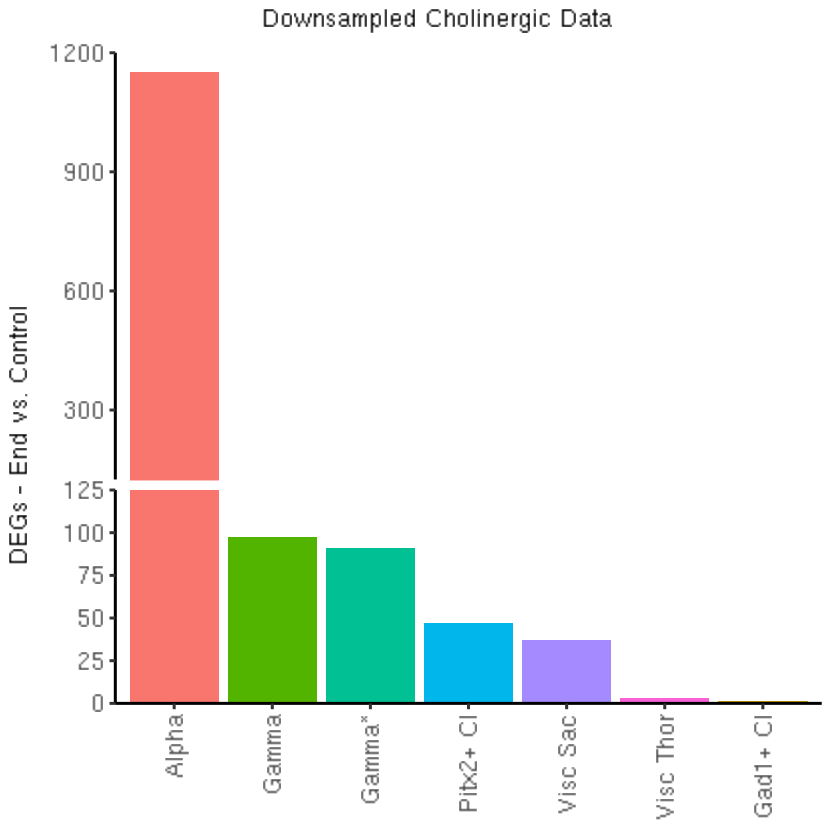

In [9]:
# End-stage downsampled

# List all CSV files in the folder containing DESeq2 differential expression results from sod.end vs. ctl
csv_files <- list.files(path = downsampled_cholinergic_end_dir, pattern = "sod.end_vs_ctl\\.csv$", full.names = TRUE)

# Initialize empty lists to store the results
cholinergic_list <- list()
cholinergic_list_up <- list()
cholinergic_list_down <- list()
cholinergic_deseq_results <- list()

# Loop through each CSV file
for (csv_file in csv_files) {
  # Read CSV as a dataframe
  df <- read.csv(csv_file, header = TRUE, row.names = 1)

  # Set the gene column to contain the row names and then remove the row names
  df$gene <- rownames(df)
  rownames(df) <- NULL

  # Filter rows with padj < 0.1
  filtered_df <- df %>% filter(padj < 0.01)
  filtered_df_up <- df %>% filter(padj < 0.01 & log2FoldChange > 0)
  filtered_df_down <- df %>% filter(padj < 0.01 & log2FoldChange < 0)

  # Get the filename without extension
  file_name <- tools::file_path_sans_ext(basename(csv_file))

  # Extract the part of the filename before the first underscore
  accessor <- str_split(file_name, "_")[[1]][1]

  # Extract the gene column
  gene_column <- filtered_df$gene
  gene_column_up <- filtered_df_up$gene
  gene_column_down <- filtered_df_down$gene

  # Add the gene column to the result list with the accessor
  cholinergic_list[[accessor]] <- gene_column
  cholinergic_list_up[[accessor]] <- gene_column_up
  cholinergic_list_down[[accessor]] <- gene_column_down

  # Add results to cholinergic_deseq_results
  cholinergic_deseq_results[[accessor]] <- df
}

# Define cholinergic_types
cholinergic_types <- names(cholinergic_list)

# Create data frame
df <- data.frame(
  cholinergic_types = cholinergic_types,
  gene_counts = sapply(cholinergic_list, length)
)

# Reorder bars in DESCENDING order by gene_count
desc_levels <- df$cholinergic_types[order(df$gene_counts, decreasing = TRUE)]
df$cholinergic_types <- factor(df$cholinergic_types, levels = desc_levels)

# Internal color mapping
cholinergic_colors <- c(
  "Alpha MNs" = "#F8766D",
  "Gad1+ Cholinergic Interneurons" = "#C49A00",
  "Gamma MNs" = "#53B400",
  "Gamma Star MNs" = "#00C094",
  "Pitx2+ Cholinergic Interneurons" = "#00B6EB",
  "Visceral Sacral MNs" = "#A58AFF",
  "Visceral Thoracic MNs" = "#FB61D7"
)
# Align to factor levels actually used
cholinergic_colors <- cholinergic_colors[levels(df$cholinergic_types)]

# Short display labels 
label_map <- c(
  "Alpha MNs" = "Alpha",
  "Gamma MNs" = "Gamma",
  "Gamma Star MNs" = "Gamma*",
  "Pitx2+ Cholinergic Interneurons" = "Pitx2+ CI",
  "Gad1+ Cholinergic Interneurons" = "Gad1+ CI",
  "Visceral Sacral MNs" = "Visc Sac",
  "Visceral Thoracic MNs" = "Visc Thor"
)
label_fn <- function(l) {
  out <- unname(label_map[l])
  out[is.na(out)] <- l[is.na(out)]
  out
}

# Plot
chol_deg_bar_plot <- ggplot(df, aes(x = cholinergic_types, y = gene_counts, fill = cholinergic_types)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cholinergic_colors, drop = FALSE) +
  scale_x_discrete(labels = label_fn) +
  labs(
    title = "Downsampled Cholinergic Data",
    x = NULL,
    y = "DEGs - End vs. Control"
  ) +
  ylim(0, 1200) +
  theme_classic(base_size = 14) +
  theme(
    legend.position = "none",
    plot.title = element_text(hjust = 0.5, size = 14),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.title = element_text(size = 14),
    axis.text  = element_text(size = 14)
  ) +
  scale_y_cut(breaks = c(125), which = c(1, 2), scales = c(1, 0.5))

chol_deg_bar_plot

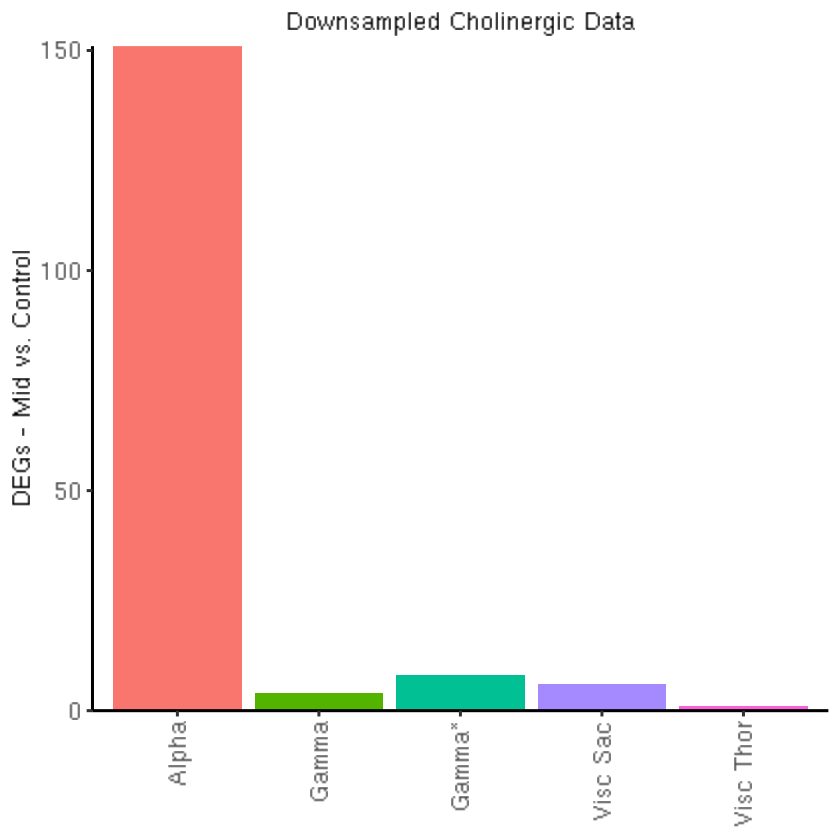

In [10]:
# Mid-stage downsampled

# List all CSV files in the folder containing DESeq2 differential expression results from sod.mid vs. ctl
csv_files <- list.files(path = downsampled_cholinergic_mid_dir, pattern = "sod.mid_vs_ctl\\.csv$", full.names = TRUE)

# Initialize empty lists to store the results
cholinergic_list <- list()
cholinergic_list_up <- list()
cholinergic_list_down <- list()
cholinergic_deseq_results <- list()

# Loop through each CSV file
for (csv_file in csv_files) {
  # Read CSV as a dataframe
  df <- read.csv(csv_file, header = TRUE, row.names = 1)

  # Set the gene column to contain the row names and then remove the row names
  df$gene <- rownames(df)
  rownames(df) <- NULL

  # Filter rows with padj < 0.1
  filtered_df <- df %>% filter(padj < 0.01)
  filtered_df_up <- df %>% filter(padj < 0.01 & log2FoldChange > 0)
  filtered_df_down <- df %>% filter(padj < 0.01 & log2FoldChange < 0)

  # Get the filename without extension
  file_name <- tools::file_path_sans_ext(basename(csv_file))

  # Extract the part of the filename before the first underscore
  accessor <- str_split(file_name, "_")[[1]][1]

  # Extract the gene column
  gene_column <- filtered_df$gene
  gene_column_up <- filtered_df_up$gene
  gene_column_down <- filtered_df_down$gene

  # Add the gene column to the result list with the accessor
  cholinergic_list[[accessor]] <- gene_column
  cholinergic_list_up[[accessor]] <- gene_column_up
  cholinergic_list_down[[accessor]] <- gene_column_down

  # Add results to cholinergic_deseq_results
  cholinergic_deseq_results[[accessor]] <- df
}

# Define cholinergic_types
cholinergic_types <- names(cholinergic_list)

# Create data frame
df <- data.frame(
  cholinergic_types = cholinergic_types,
  gene_counts = sapply(cholinergic_list, length)
)

# Internal color mapping (defines order)
cholinergic_colors <- c(
  "Alpha MNs" = "#F8766D",
  "Gamma MNs" = "#53B400",
  "Gamma Star MNs" = "#00C094",
  "Visceral Sacral MNs" = "#A58AFF",
  "Visceral Thoracic MNs" = "#FB61D7"
)

# Set factor levels to match desired order
desired_order <- names(cholinergic_colors)
df$cholinergic_types <- factor(df$cholinergic_types, levels = desired_order)

# Align colors to actual levels
cholinergic_colors <- cholinergic_colors[levels(df$cholinergic_types)]

# Short display labels
label_map <- c(
  "Alpha MNs" = "Alpha",
  "Gamma MNs" = "Gamma",
  "Gamma Star MNs" = "Gamma*",
  "Visceral Sacral MNs" = "Visc Sac",
  "Visceral Thoracic MNs" = "Visc Thor"
)

label_fn <- function(l) {
  out <- unname(label_map[l])
  out[is.na(out)] <- l[is.na(out)]
  out
}

# Plot
chol_deg_bar_plot_mid <- ggplot(df, aes(x = cholinergic_types, y = gene_counts, fill = cholinergic_types)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cholinergic_colors, drop = FALSE) +
  scale_x_discrete(labels = label_fn) +
  scale_y_continuous(expand = c(0, 0)) +
  labs(
    title = "Downsampled Cholinergic Data",
    x = NULL,
    y = "DEGs - Mid vs. Control"
  ) +
  theme_classic(base_size = 14) +
  theme(
    legend.position = "none",
    plot.title = element_text(hjust = 0.5, size = 14),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.title = element_text(size = 14),
    axis.text  = element_text(size = 14)
  )

chol_deg_bar_plot_mid

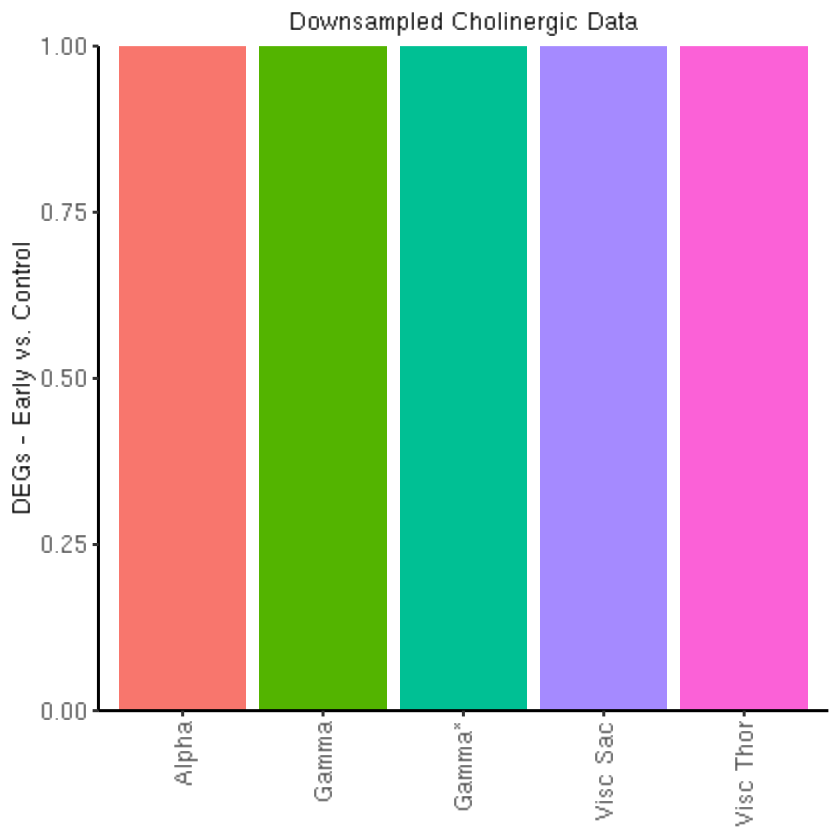

In [11]:
# Early-stage downsampled

# List all CSV files in the folder containing DESeq2 differential expression results from sod.early vs. ctl
csv_files <- list.files(path = downsampled_cholinergic_early_dir, pattern = "sod.early_vs_ctl\\.csv$", full.names = TRUE)

# Initialize empty lists to store the results
cholinergic_list <- list()
cholinergic_list_up <- list()
cholinergic_list_down <- list()
cholinergic_deseq_results <- list()

# Loop through each CSV file
for (csv_file in csv_files) {
  # Read CSV as a dataframe
  df <- read.csv(csv_file, header = TRUE, row.names = 1)

  # Set the gene column to contain the row names and then remove the row names
  df$gene <- rownames(df)
  rownames(df) <- NULL

  # Filter rows with padj < 0.1
  filtered_df <- df %>% filter(padj < 0.01)
  filtered_df_up <- df %>% filter(padj < 0.01 & log2FoldChange > 0)
  filtered_df_down <- df %>% filter(padj < 0.01 & log2FoldChange < 0)

  # Get the filename without extension
  file_name <- tools::file_path_sans_ext(basename(csv_file))

  # Extract the part of the filename before the first underscore
  accessor <- str_split(file_name, "_")[[1]][1]

  # Extract the gene column
  gene_column <- filtered_df$gene
  gene_column_up <- filtered_df_up$gene
  gene_column_down <- filtered_df_down$gene

  # Add the gene column to the result list with the accessor
  cholinergic_list[[accessor]] <- gene_column
  cholinergic_list_up[[accessor]] <- gene_column_up
  cholinergic_list_down[[accessor]] <- gene_column_down

  # Add results to cholinergic_deseq_results
  cholinergic_deseq_results[[accessor]] <- df
}

# Define cholinergic_types
cholinergic_types <- names(cholinergic_list)

# Create data frame
df <- data.frame(
  cholinergic_types = cholinergic_types,
  gene_counts = sapply(cholinergic_list, length)
)

# Reorder bars in DESCENDING order by gene_count
desc_levels <- df$cholinergic_types[order(df$gene_counts, decreasing = TRUE)]
df$cholinergic_types <- factor(df$cholinergic_types, levels = desc_levels)

# Internal color mapping
cholinergic_colors <- c(
  "Alpha MNs" = "#F8766D",
  "Gamma MNs" = "#53B400",
  "Gamma Star MNs" = "#00C094",
  "Visceral Sacral MNs" = "#A58AFF",
  "Visceral Thoracic MNs" = "#FB61D7"
)
# Align to factor levels actually used
cholinergic_colors <- cholinergic_colors[levels(df$cholinergic_types)]

# Short display labels 
label_map <- c(
  "Alpha MNs" = "Alpha",
  "Gamma MNs" = "Gamma",
  "Gamma Star MNs" = "Gamma*",
  "Visceral Sacral MNs" = "Visc Sac",
  "Visceral Thoracic MNs" = "Visc Thor"
)
label_fn <- function(l) {
  out <- unname(label_map[l])
  out[is.na(out)] <- l[is.na(out)]
  out
}

# Plot
chol_deg_bar_plot_early <- ggplot(df, aes(x = cholinergic_types, y = gene_counts, fill = cholinergic_types)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = cholinergic_colors, drop = FALSE) +
  scale_x_discrete(labels = label_fn) +
  scale_y_continuous(expand = c(0, 0)) +
  labs(
    title = "Downsampled Cholinergic Data",
    x = NULL,
    y = "DEGs - Early vs. Control"
  ) +
  #ylim(0, 1200) +
  theme_classic(base_size = 14) +
  theme(
    legend.position = "none",
    plot.title = element_text(hjust = 0.5, size = 14),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.title = element_text(size = 14),
    axis.text  = element_text(size = 14)
  )

chol_deg_bar_plot_early

## hSOD1 Expression Across Cholinergic Types


# A tibble: 7 × 2
  cholinergic_type n_experiments
  <fct>                    <int>
1 Alpha                       13
2 Gamma                       12
3 Gamma*                      12
4 Pitx2+ CI                   12
5 Visc Sac                    13
6 Visc Thor                   15
7 Gad1+ CI                    11


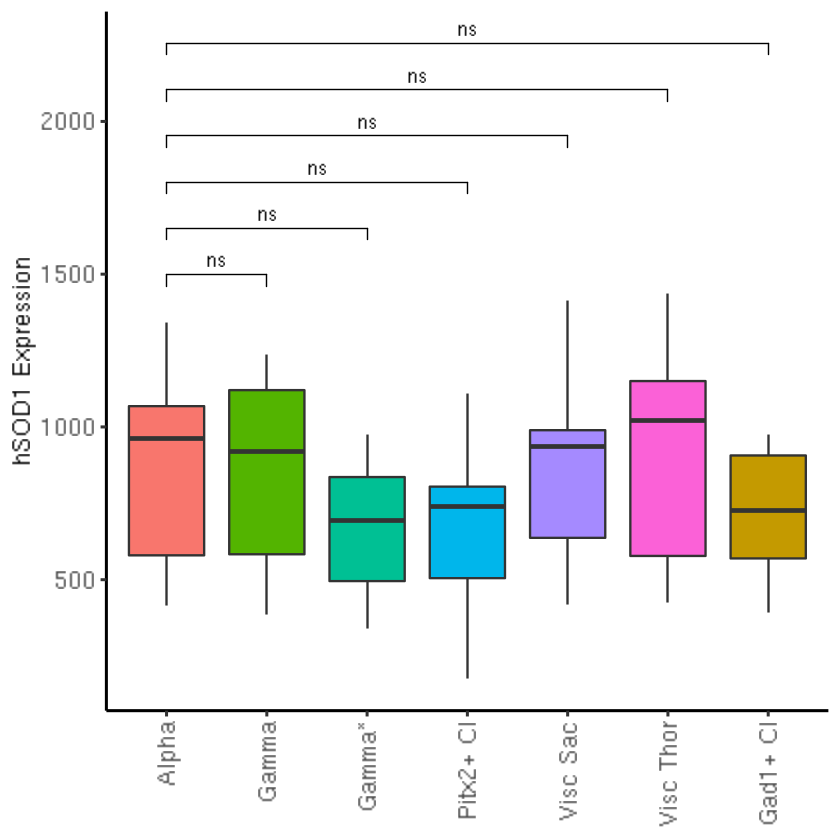

In [12]:
# Subset to SOD1 stages and normalize to CPM
cholinergic_sod1 <- subset(cholinergic_annotated, subset = stage %in% c("sod.early", "sod.mid", "sod.end"))
cholinergic_sod1_cpm <- NormalizeData(cholinergic_sod1, normalization.method = "RC", scale.factor = 1e6)

# Combine metadata and expression of hSOD1
cholinergic_sod1_cpm$orig.ident_type <- paste(cholinergic_sod1_cpm$orig.ident,
                                              cholinergic_sod1_cpm$cholinergic_type,
                                              sep = "_")
hSOD1_expr <- FetchData(cholinergic_sod1_cpm, vars = "hSOD1")
meta_expr <- bind_cols(cholinergic_sod1_cpm@meta.data, hSOD1_expr)

# Filter out groups with <=10 cells and compute per-experiment averages
meta_expr_filtered <- meta_expr %>%
  group_by(orig.ident, cholinergic_type) %>%
  filter(n() > 10) %>%
  summarise(avg_hSOD1 = mean(hSOD1), .groups = "drop")

# Map long -> short names
label_map <- c(
  "Alpha MNs"                        = "Alpha",
  "Gamma MNs"                        = "Gamma",
  "Gamma Star MNs"                   = "Gamma*",
  "Pitx2+ Cholinergic Interneurons"  = "Pitx2+ CI",
  "Gad1+ Cholinergic Interneurons"   = "Gad1+ CI",
  "Visceral Sacral MNs"              = "Visc Sac",
  "Visceral Thoracic MNs"            = "Visc Thor"
)

# Desired order 
ordered_types_long  <- c("Alpha MNs", "Gamma MNs", "Gamma Star MNs",
                         "Pitx2+ Cholinergic Interneurons",
                         "Visceral Sacral MNs", "Visceral Thoracic MNs",
                         "Gad1+ Cholinergic Interneurons")
ordered_types_short <- unname(label_map[ordered_types_long])

# Apply renaming + factor order
meta_expr_filtered <- meta_expr_filtered %>%
  mutate(cholinergic_type = recode(cholinergic_type, !!!label_map)) %>%
  mutate(cholinergic_type = factor(cholinergic_type, levels = ordered_types_short))

# Colors named by short labels
cholinergic_colors_short <- c(
  "Alpha"      = "#F8766D",
  "Gamma"      = "#53B400",
  "Gamma*"     = "#00C094",
  "Pitx2+ CI"  = "#00B6EB",
  "Visc Sac"   = "#A58AFF",
  "Visc Thor"  = "#FB61D7",
  "Gad1+ CI"   = "#C49A00"
)

# Pairwise comparisons vs Alpha 
pairwise_comparisons <- lapply(ordered_types_short[-1], function(x) c("Alpha", x))

# Boxplot with Welch's t-test + BH/FDR and centered x labels
boxplot <- ggplot(meta_expr_filtered,
                  aes(x = cholinergic_type, y = avg_hSOD1, fill = cholinergic_type)) +
  geom_boxplot(outlier.size = 0.7) +
  labs(x = NULL, y = "hSOD1 Expression") +
  scale_fill_manual(values = cholinergic_colors_short, drop = FALSE) +
  stat_compare_means(
    method = "t.test",                    # Welch by default
    method.args = list(var.equal = FALSE),
    comparisons = pairwise_comparisons,
    p.adjust.method = "BH",
    label = "p.signif",
    hide.ns = FALSE
  ) +
  theme_classic(base_size = 14) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 14),
    text        = element_text(size = 14),
    axis.text.y = element_text(size = 14)
  )

boxplot

# Print number of experiments per cholinergic type
meta_expr_filtered %>%
  group_by(cholinergic_type) %>%
  summarise(n_experiments = n_distinct(orig.ident)) %>%
  print()

## Alpha/Gamma/Gamma* DEG Overlaps and Susceptibility Overlap


In [13]:
# List all CSV files in the folder containing DESeq2 differential expression results from sod.end vs. ctl
csv_files <- list.files(path = cholinergic_type_dir, pattern = "sod.end_vs_ctl\\.csv$", full.names = TRUE)

# Initialize empty lists to store the results
venn_list <- list()
venn_list_up <- list()
venn_list_down <- list()
cholinergic_deseq_results <- list()

# Loop through each CSV file
for (csv_file in csv_files) {
  # Read CSV as a dataframe
  df <- read.csv(csv_file, header = TRUE, row.names = 1)
    
  # Set the gene column to contain the row names and then remove the row names
  df$gene <- rownames(df)
  rownames(df) <- NULL
  
  # Filter rows with padj < 0.1
  filtered_df <- df %>% filter(padj < 0.01)
  filtered_df_up <- df %>% filter(padj < 0.01 & log2FoldChange > 0)
  filtered_df_down <- df %>% filter(padj < 0.01 & log2FoldChange < 0)
  
  # Get the filename without extension
  file_name <- tools::file_path_sans_ext(basename(csv_file))
  
  # Extract the part of the filename before the first underscore
  accessor <- str_split(file_name, "_")[[1]][1]
  
  # Extract the gene column
  gene_column <- filtered_df$gene
  gene_column_up <- filtered_df_up$gene
  gene_column_down <- filtered_df_down$gene
  
  # Add the gene column to the result list with the accessor
  venn_list[[accessor]] <- gene_column
  venn_list_up[[accessor]] <- gene_column_up
  venn_list_down[[accessor]] <- gene_column_down
    
  # Add results to cholinergic_deseq_results
  cholinergic_deseq_results[[accessor]] <- df 
}

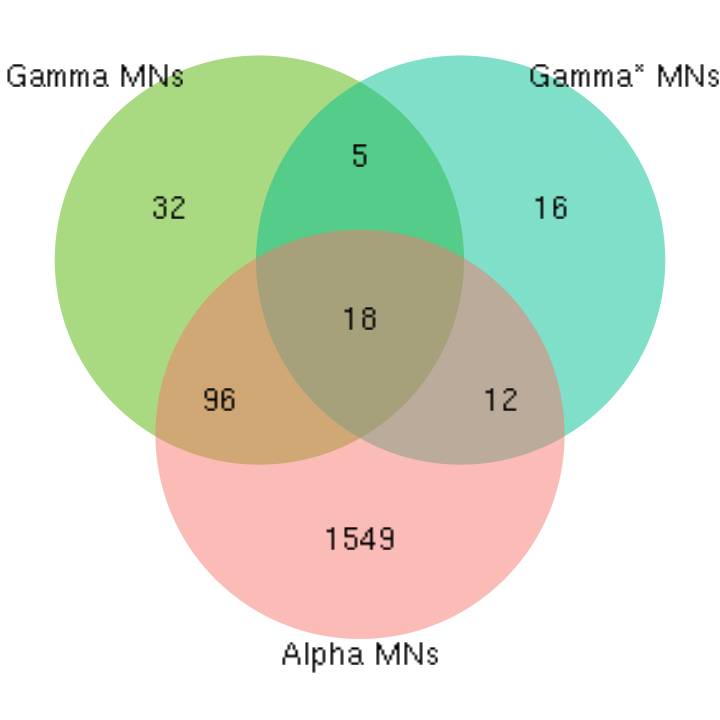

In [14]:
# Upregulated
options(repr.plot.width = 6, repr.plot.height = 6)

skeletal_up_venn <- venn.diagram(
  x = list(
    set1 = venn_list_up$`Gamma MNs`,
    set2 = venn_list_up$`Gamma Star MNs`,
    set3 = venn_list_up$`Alpha MNs`
  ),
  category.names = c("Gamma MNs", "Gamma* MNs", "Alpha MNs"),
  filename = NULL,
  lwd = 2,
  lty = "blank",
  fill = c("#53B400", "#00C094", "#F8766D"),
  cat.fontfamily = "sans",
  fontfamily = "sans",
  cat.cex = 1.5,
  cex = 1.5,
  margin = 0.05
)

grid.newpage()
grid.draw(skeletal_up_venn)

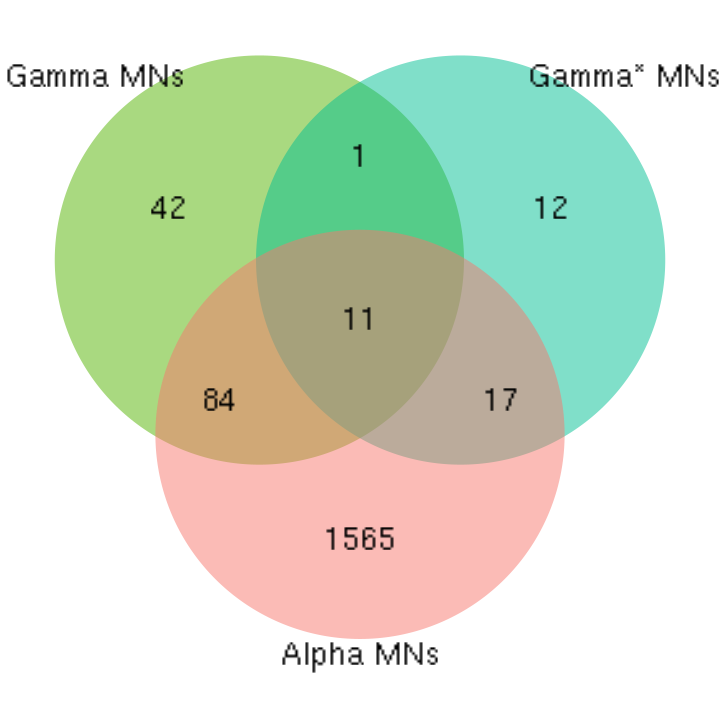

In [15]:
# Downregulated
options(repr.plot.width = 6, repr.plot.height = 6)

skeletal_down_venn <- venn.diagram(
    x = list(set1 = venn_list_down$`Gamma MNs`, set2 = venn_list_down$`Gamma Star MNs`, set3 = venn_list_down$`Alpha MNs`),
            category.names =  c("Gamma MNs", "Gamma* MNs", "Alpha MNs"),
            filename = NULL, 
            lwd = 2,
            lty = 'blank',
            fill = c("#53B400", "#00C094", "#F8766D"),
            imagetype='svg',
            cat.fontfamily = "sans",
            fontfamily = "sans",
            cat.cex = 1.5,
            cex = 1.5,
            margin=0.05,
            width=30, height=30)

grid.newpage()
grid.draw(skeletal_down_venn)

## Sciatic Nerve Crush Comparison Plots/Tables


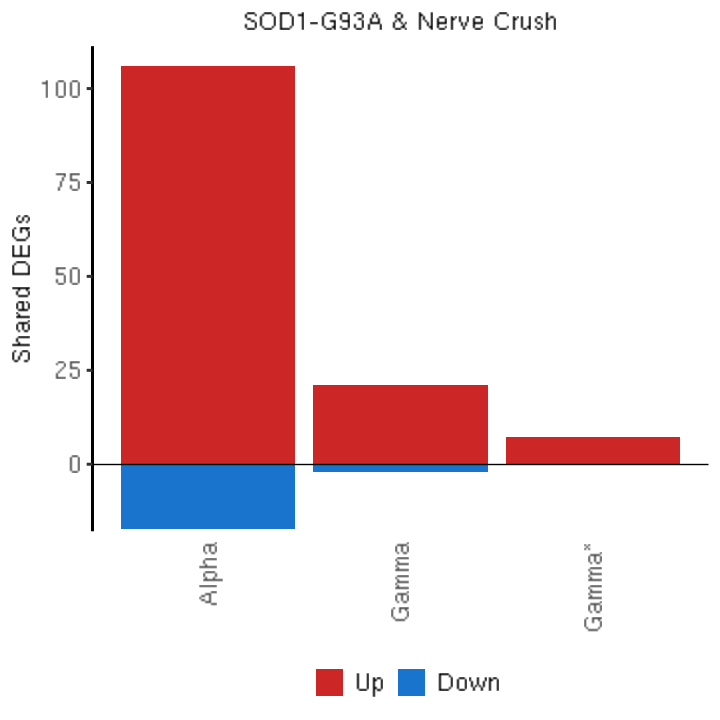

In [16]:
nerve_injury <- read.csv(nerve_injury_file)

nerve_injury_sig <- dplyr::filter(nerve_injury, significant == "yes")
nerve_injury_up <- dplyr::filter(nerve_injury_sig, log2.fold_change. > 0)
nerve_injury_down <- dplyr::filter(nerve_injury_sig, log2.fold_change. < 0)

alpha_disease_nerve_injury_up <- intersect(venn_list_up$`Alpha MNs`, nerve_injury_up$gene)
gammaStar_disease_nerve_injury_up <- intersect(venn_list_up$`Gamma Star MNs`, nerve_injury_up$gene)
gamma_disease_nerve_injury_up <- intersect(venn_list_up$`Gamma MNs`, nerve_injury_up$gene)

alpha_disease_nerve_injury_down <- intersect(venn_list_down$`Alpha MNs`, nerve_injury_down$gene)
gammaStar_disease_nerve_injury_down <- intersect(venn_list_down$`Gamma Star MNs`, nerve_injury_down$gene)
gamma_disease_nerve_injury_down <- intersect(venn_list_down$`Gamma MNs`, nerve_injury_down$gene)

# Create a dataframe
disease_nerve_injury_df <- data.frame(
  Category = c("Alpha MNs", "Gamma Star MNs", "Gamma MNs"),
  Up = c(length(alpha_disease_nerve_injury_up), length(gammaStar_disease_nerve_injury_up), length(gamma_disease_nerve_injury_up)),
  Down = c(length(alpha_disease_nerve_injury_down)*-1, length(gammaStar_disease_nerve_injury_down)*-1, length(gamma_disease_nerve_injury_down)*-1)
)

# Convert the dataframe to long format and change Gamma* label
disease_nerve_injury_long <- tidyr::pivot_longer(
  disease_nerve_injury_df,
  cols = c(Up, Down),
  names_to = "Direction",
  values_to = "Count"
)

disease_nerve_injury_long <- disease_nerve_injury_long %>%
  mutate(
    Category = dplyr::recode(
      Category,
      "Alpha MNs"       = "Alpha",
      "Gamma MNs"       = "Gamma",
      "Gamma Star MNs"  = "Gamma*",
      .default = Category,
      .missing = Category
    )
  )

disease_nerve_injury_shared_barplot <- ggplot(disease_nerve_injury_long, aes(x = Category, y = Count, fill = Direction)) +
  geom_bar(stat = "identity", position = "identity") +
  geom_hline(yintercept = 0, color = "black", size = 0.3) +
  scale_fill_manual(values = c("Up" = "firebrick3", "Down" = "dodgerblue3")) +
  labs(x = NULL, y = "Shared DEGs") +
  ggtitle("SOD1-G93A & Nerve Crush") +
  theme_classic(base_size = 14) +
  theme(
    plot.title   = element_text(hjust = 0.5, size = 14),
    axis.text.x  = element_text(size = 14, angle = 90, hjust = 1, vjust = 0.5),
    axis.text.y  = element_text(size = 14),
    axis.title.y = element_text(size = 14),
    legend.text  = element_text(size = 14),
    legend.title = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line.x  = element_blank(),
    legend.position = "bottom"   # <- move legend to bottom
  ) +
  scale_y_continuous(
    limits = c(min(disease_nerve_injury_long$Count) * 1.05,
               max(disease_nerve_injury_long$Count) * 1.05),
    expand = c(0, 0)
  )

disease_nerve_injury_shared_barplot